<a href="https://colab.research.google.com/github/Bercine/Deep-learning-with-python-Francois-Chollet/blob/main/chap_5_Fundamentals_of_machine_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
%reset -f

#Listing 5.1 Adding white noise channels or all-zeros channels to MNIST


In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np

In [ ]:
(train_images, train_labels), _ =mnist.load_data()
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype("float32") / 255

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
train_images_with_noise_channels = np.concatenate([
    train_images, np.random.random((len(train_images), 784))], axis=1)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1)

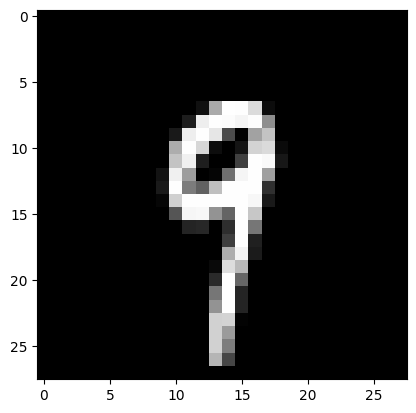

In [ ]:
import matplotlib.pyplot as plt

# Afficher la première image
plt.imshow(train_images[600].reshape(28, 28), cmap="gray")
plt.show()

#Listing 5.2 Training the same model on MNIST data with noise channels or all-zero channels


In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
def get_model():
  model = keras.Sequential([
      layers.Dense(512, activation="relu"),
      layers.Dense(10, activation="softmax")
  ])
  model.compile(optimizer="rmsprop",
                loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])
  return model


In [ ]:
model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels, train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8159 - loss: 0.5994 - val_accuracy: 0.8944 - val_loss: 0.3251
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9224 - loss: 0.2483 - val_accuracy: 0.9457 - val_loss: 0.1780
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9499 - loss: 0.1636 - val_accuracy: 0.9551 - val_loss: 0.1520
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9645 - loss: 0.1150 - val_accuracy: 0.9523 - val_loss: 0.1604
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9726 - loss: 0.0859 - val_accuracy: 0.9633 - val_loss: 0.1307
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9810 - loss: 0.0609 - val_accuracy: 0.9604 - val_loss: 0.1414
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9853 - loss: 0.0465 - val_accuracy: 0.9672 - val_loss: 0.1227
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9897 - loss: 0.0341 - val_accuracy: 0.

In [ ]:
history_noise

#Listing 5.3 Plotting a validation accuracy comparison


In [ ]:
import matplotlib.pyplot as plt

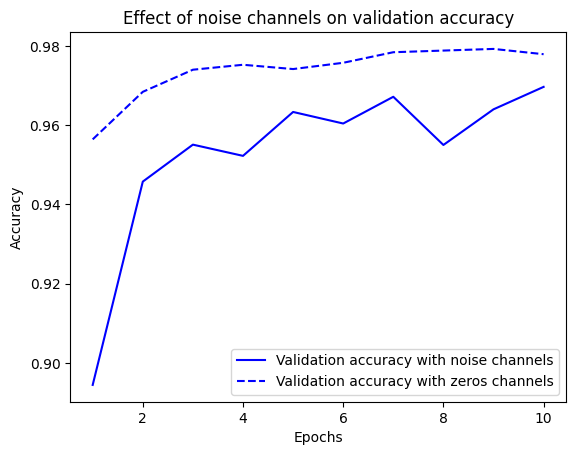

In [ ]:
val_acc_noise = history_noise.history['val_accuracy']
val_acc_zeros = history_zeros.history['val_accuracy']
epochs = range(1, 11)
plt.plot(epochs, val_acc_noise, "b-",
         label="Validation accuracy with noise channels")
plt.plot(epochs, val_acc_zeros, "b--",
         label="Validation accuracy with zeros channels")
plt.title("Effect of noise channels on validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#Listing 5.4 Fitting an MNIST model with randomly shuffled labels


In [ ]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

In [ ]:
random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

In [ ]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='rmsprop',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(
    train_images, random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1047 - loss: 2.3150 - val_accuracy: 0.1005 - val_loss: 2.3096
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1172 - loss: 2.2985 - val_accuracy: 0.1007 - val_loss: 2.3129
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1320 - loss: 2.2903 - val_accuracy: 0.1081 - val_loss: 2.3173
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1397 - loss: 2.2787 - val_accuracy: 0.1061 - val_loss: 2.3266
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1526 - loss: 2.2629 - val_accuracy: 0.1042 - val_loss: 2.3310
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1686 - loss: 2.2431 - val_accuracy: 0.1044 - val_loss: 2.3603
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1819 - loss: 2.2201 - val_accuracy: 0.1003 - val_loss: 2.3662
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1981 - loss: 2.1946 - val_accu

#K-Fold


In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist
from tensorflow import keras
from tensorflow.keras import layers

# Charger les données
(images_entrainement, labels_entrainement), (images_test, labels_test) = mnist.load_data()

# Prétraiter
images_entrainement = images_entrainement.reshape(60000, 784).astype("float32") / 255

# Petit sous-ensemble
small_data = images_entrainement[:1000]
small_labels = labels_entrainement[:1000]

# Modèle
def build_model():
    model = keras.Sequential([
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(optimizer="rmsprop",
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


In [ ]:
# Iterated K-fold validation
num_iterations = 2
num_folds = 5
all_scores = []

for i in range(num_iterations):
    indices = np.arange(len(small_data))
    np.random.shuffle(indices)
    shuffled_data = small_data[indices]
    shuffled_labels = small_labels[indices]

    val_samples = len(small_data) // num_folds
    fold_scores = []

    for f in range(num_folds):
        val_start = f * val_samples
        val_end = (f + 1) * val_samples

        val_data = shuffled_data[val_start:val_end]
        val_labels = shuffled_labels[val_start:val_end]
        train_data = np.concatenate([shuffled_data[:val_start], shuffled_data[val_end:]])
        train_labels = np.concatenate([shuffled_labels[:val_start], shuffled_labels[val_end:]])

        model = build_model()
        model.fit(train_data, train_labels, epochs=3, batch_size=32, verbose=0)
        loss, acc = model.evaluate(val_data, val_labels, verbose=0)
        fold_scores.append(acc)
        print(f"Itération {i+1}, Fold {f+1}: {acc:.4f}")

    all_scores.extend(fold_scores)

print(f"Scores individuels: {all_scores}")
print(f"Moyenne finale: {np.mean(all_scores):.4f}")
print(f"Écart-type: {np.std(all_scores):.4f}")


NameError: name 'np' is not defined

#Listing 5.7 Training an MNIST model with an incorrectly high learning rate


In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28*28))
train_images = train_images.astype('float32') / 255

In [ ]:
model = keras.Sequential([
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer=keras.optimizers.RMSprop(1.),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.2882 - loss: 707.7369 - val_accuracy: 0.1898 - val_loss: 2.3127
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1920 - loss: 2.7653 - val_accuracy: 0.1723 - val_loss: 2.1914
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2001 - loss: 2.7393 - val_accuracy: 0.1973 - val_loss: 2.2721
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2005 - loss: 2.3641 - val_accuracy: 0.1853 - val_loss: 2.1379
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1982 - loss: 2.5415 - val_accuracy: 0.2215 - val_loss: 2.2305
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2176 - loss: 2.4150 - val_accuracy: 0.2134 - val_loss: 2.2330
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2035 - loss: 2.5418 - val_accuracy: 0.2077 - val_loss: 2.1488
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.2039 - loss: 2.4157 - val_accuracy: 

#Listing 5.8 The same model with a more appropriate learning rate


In [ ]:
model = keras.Sequential([
    layers.Dense(512, activation='relu'),
    layers.Dense(10, activation='softmax')
])
model.compile(optimizer=keras.optimizers.RMSprop(1e-2),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels,
          epochs=10,
          batch_size=128,
          validation_split=0.2)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9104 - loss: 0.3560 - val_accuracy: 0.9531 - val_loss: 0.1669
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9654 - loss: 0.1276 - val_accuracy: 0.9622 - val_loss: 0.1501
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9735 - loss: 0.1000 - val_accuracy: 0.9738 - val_loss: 0.1306
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9785 - loss: 0.0858 - val_accuracy: 0.9717 - val_loss: 0.1349
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9817 - loss: 0.0725 - val_accuracy: 0.9740 - val_loss: 0.1513
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9852 - loss: 0.0617 - val_accuracy: 0.9621 - val_loss: 0.2337
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9881 - loss: 0.0494 - val_accuracy: 0.9718 - val_loss: 0.1943
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9888 - loss: 0.0506 - val_accuracy: 0.

#Listing 5.9 A simple logistic regression on MNIST


In [ ]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(optimizer="rmsprop",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"])
history_small_model = model.fit(
    train_images, train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8377 - loss: 0.6639 - val_accuracy: 0.9030 - val_loss: 0.3612
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9018 - loss: 0.3538 - val_accuracy: 0.9132 - val_loss: 0.3112
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9119 - loss: 0.3180 - val_accuracy: 0.9158 - val_loss: 0.2951
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9156 - loss: 0.3018 - val_accuracy: 0.9207 - val_loss: 0.2841
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9191 - loss: 0.2921 - val_accuracy: 0.9234 - val_loss: 0.2789
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9200 - loss: 0.2857 - val_accuracy: 0.9238 - val_loss: 0.2755
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9219 - loss: 0.2804 - val_accuracy: 0.9237 - val_loss: 0.2725
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9229 - loss: 0.2767 - val_accuracy: 0.

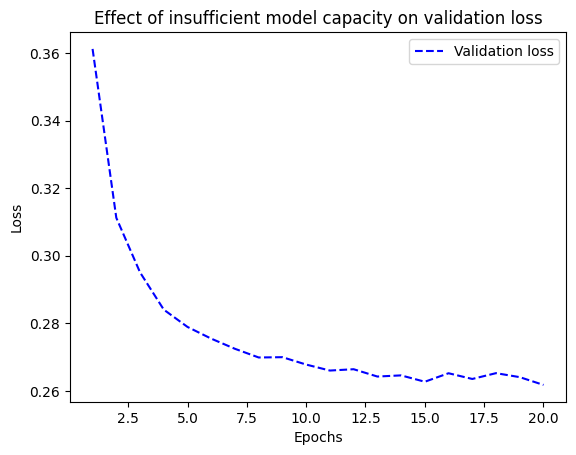

In [ ]:
import matplotlib.pyplot as plt
val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b--",
 label="Validation loss")
plt.title("Effect of insufficient model capacity on validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
model = keras.Sequential([
    layers.Dense(96, activation="relu"),
    layers.Dense(96, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
model.compile(optimizer="rmsprop",
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"])
history_large_model = model.fit(
    train_images, train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8944 - loss: 0.3736 - val_accuracy: 0.9424 - val_loss: 0.2001
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9501 - loss: 0.1673 - val_accuracy: 0.9588 - val_loss: 0.1412
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9645 - loss: 0.1195 - val_accuracy: 0.9652 - val_loss: 0.1193
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9718 - loss: 0.0932 - val_accuracy: 0.9658 - val_loss: 0.1101
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9778 - loss: 0.0748 - val_accuracy: 0.9692 - val_loss: 0.1039
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0617 - val_accuracy: 0.9710 - val_loss: 0.1003
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9846 - loss: 0.0508 - val_accuracy: 0.9720 - val_loss: 0.0976
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9870 - loss: 0.0431 - val_accuracy: 0.

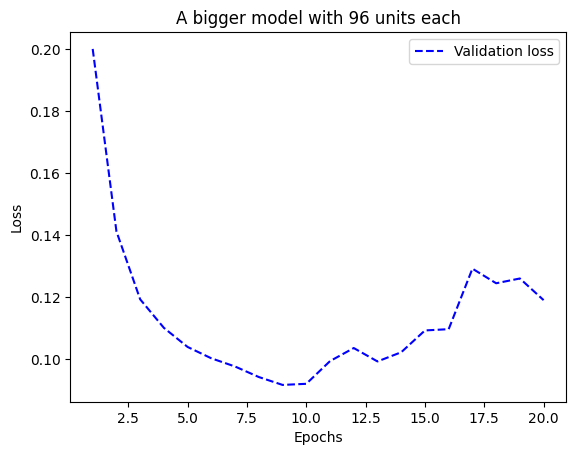

In [ ]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b--",
 label="Validation loss")
plt.title("A bigger model with 96 units each")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

#Listing 5.10 Original model


In [ ]:
from tensorflow.keras.datasets import imdb
(train_data, train_labels), _ = imdb.load_data(num_words=10000)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
import numpy as np

In [ ]:
train_data.shape

(25000,)

In [ ]:
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

# Décoder la première critique
decoded_review = " ".join([reverse_word_index.get(i - 3, "?") for i in train_data[0]])
print(decoded_review)

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should

In [ ]:
def vectorize_sequences(sequences, dimensions=10000):
  results = np.zeros((len(sequences), dimensions))
  for i, sequence in enumerate(sequences):
    results[i, sequence] = 1.
  return results
train_data = vectorize_sequences(train_data)

In [ ]:
model = keras.Sequential([
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
      loss="binary_crossentropy",
      metrics=["accuracy"])
history_original = model.fit(train_data, train_labels,
                     epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 85ms/step - accuracy: 0.7623 - loss: 0.5399 - val_accuracy: 0.8550 - val_loss: 0.4062
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.8927 - loss: 0.3304 - val_accuracy: 0.8843 - val_loss: 0.3149
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9203 - loss: 0.2436 - val_accuracy: 0.8927 - val_loss: 0.2821
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9361 - loss: 0.1955 - val_accuracy: 0.8904 - val_loss: 0.2760
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9489 - loss: 0.1634 - val_accuracy: 0.8879 - val_loss: 0.2764
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9568 - loss: 0.1346 - val_accuracy: 0.8859 - val_loss: 0.2871
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9635 - loss: 0.1178 - val_accuracy: 0.8836 - val_loss: 0.3044
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9703 - loss: 0.1015 - val_accuracy: 0.8842 - v

#Listing 5.11 Version of the model with lower capacity


In [ ]:
model = keras.Sequential([
    layers.Dense(4, activation="relu"),
    layers.Dense(4, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
      loss="binary_crossentropy",
      metrics=["accuracy"])
history_smaller_model = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.6187 - loss: 0.6317 - val_accuracy: 0.6436 - val_loss: 0.5898
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.7767 - loss: 0.5472 - val_accuracy: 0.8151 - val_loss: 0.5372
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8375 - loss: 0.4987 - val_accuracy: 0.8251 - val_loss: 0.5050
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8735 - loss: 0.4583 - val_accuracy: 0.8239 - val_loss: 0.4807
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9012 - loss: 0.4126 - val_accuracy: 0.8417 - val_loss: 0.4431
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9205 - loss: 0.3585 - val_accuracy: 0.8707 - val_loss: 0.3925
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9359 - loss: 0.3027 - val_accuracy: 0.8776 - val_loss: 0.3529
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9440 - loss: 0.2548 - val_accuracy: 0.8759 - v

In [ ]:
import matplotlib.pyplot as plt

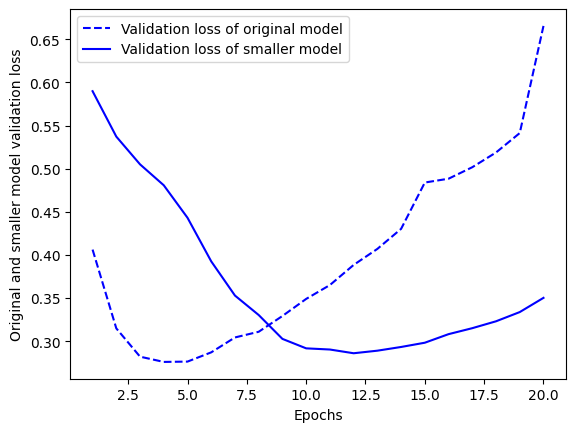

In [ ]:
val_loss_original = history_original.history['val_loss']
val_loss_smaller = history_smaller_model.history['val_loss']
epochs = range(1,21)
plt.plot(epochs, val_loss_original, 'b--', label='Validation loss of original model')
plt.plot(epochs, val_loss_smaller, 'b', label='Validation loss of smaller model')
plt.xlabel('Epochs')
plt.ylabel('Original and smaller model validation loss')
plt.legend()
plt.show()

#Listing 5.12 Version of the model with higher capacity


In [ ]:
model = keras.Sequential([
    layers.Dense(512, activation="relu"),
    layers.Dense(512, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])
model.compile(optimizer="rmsprop",
      loss="binary_crossentropy",
      metrics=["accuracy"])
history_larger_model = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.7063 - loss: 0.5717 - val_accuracy: 0.8717 - val_loss: 0.3498
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8719 - loss: 0.3299 - val_accuracy: 0.8749 - val_loss: 0.3011
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9084 - loss: 0.2313 - val_accuracy: 0.8536 - val_loss: 0.3587
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9259 - loss: 0.1867 - val_accuracy: 0.8771 - val_loss: 0.2996
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9467 - loss: 0.1425 - val_accuracy: 0.8779 - val_loss: 0.3229
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9517 - loss: 0.1252 - val_accuracy: 0.8878 - val_loss: 0.2869
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9744 - loss: 0.0762 - val_accuracy: 0.8847 - val_loss: 0.3452
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9785 - loss: 0.0668 - val_accuracy: 0.8847 - v

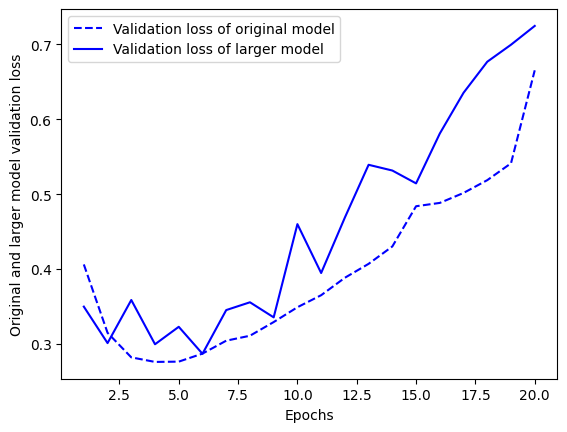

In [ ]:
val_loss_larger = history_larger_model.history['val_loss']
plt.plot(epochs, val_loss_original, 'b--', label='Validation loss of original model')
plt.plot(epochs, val_loss_larger, 'b', label='Validation loss of larger model')
plt.xlabel('Epochs')
plt.ylabel('Original and larger model validation loss')
plt.legend()
plt.show()

#Listing 5.13 Adding L2 weight regularization to the model


In [ ]:
from tensorflow.keras import regularizers

In [ ]:
model = keras.Sequential([
    layers.Dense(16, kernel_regularizer=regularizers.l2(0.002), activation='relu'),
    layers.Dense(16, kernel_regularizer=regularizers.l2(0.002), activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
history_l2_reg = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.7682 - loss: 0.6562 - val_accuracy: 0.8597 - val_loss: 0.5275
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8803 - loss: 0.4586 - val_accuracy: 0.8769 - val_loss: 0.4260
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9010 - loss: 0.3759 - val_accuracy: 0.8756 - val_loss: 0.3983
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9171 - loss: 0.3271 - val_accuracy: 0.8742 - val_loss: 0.3887
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9211 - loss: 0.3049 - val_accuracy: 0.8815 - val_loss: 0.3699
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9267 - loss: 0.2866 - val_accuracy: 0.8877 - val_loss: 0.3572
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9374 - loss: 0.2685 - val_accuracy: 0.8777 - val_loss: 0.3726
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9365 - loss: 0.2617 - val_accuracy: 0.8841 - v

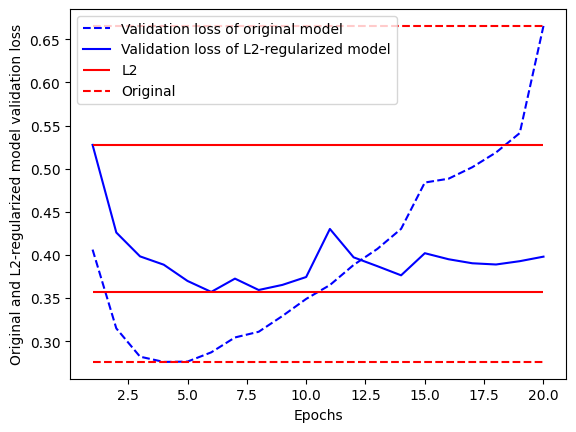

In [ ]:
val_loss_l2_reg = history_l2_reg.history['val_loss']
plt.plot(epochs, val_loss_original, 'b--', label='Validation loss of original model')
plt.plot(epochs, val_loss_l2_reg, 'b', label='Validation loss of L2-regularized model')
plt.xlabel('Epochs')
plt.ylabel('Original and L2-regularized model validation loss')
plt.hlines(max(val_loss_l2_reg), epochs[0], epochs[-1], colors='red', label='L2')
plt.hlines(min(val_loss_l2_reg), epochs[0], epochs[-1], colors='red')

plt.hlines(max(val_loss_original), epochs[0], epochs[-1], colors='red', linestyles='dashed', label='Original')
plt.hlines(min(val_loss_original), epochs[0], epochs[-1], colors='red', linestyles='dashed')

plt.legend()
plt.show()

#Listing 5.14 Different weight regularizers available in Keras


In [ ]:
from tensorflow.keras import regularizers
regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

#Listing 5.15 Adding dropout to the IMDB model


In [ ]:
model = keras.Sequential([
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_dropout = model.fit(
    train_data, train_labels,
    epochs=20, batch_size=512, validation_split=0.4
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 114ms/step - accuracy: 0.5968 - loss: 0.6563 - val_accuracy: 0.8384 - val_loss: 0.5537
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.7345 - loss: 0.5463 - val_accuracy: 0.8720 - val_loss: 0.4313
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8003 - loss: 0.4587 - val_accuracy: 0.8807 - val_loss: 0.3600
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8395 - loss: 0.3937 - val_accuracy: 0.8745 - val_loss: 0.3334
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8721 - loss: 0.3412 - val_accuracy: 0.8852 - val_loss: 0.2972
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8892 - loss: 0.3031 - val_accuracy: 0.8921 - val_loss: 0.2762
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9041 - loss: 0.2730 - val_accuracy: 0.8898 - val_loss: 0.2760
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.9122 - loss: 0.2398 - val_accuracy: 0.8890 - 

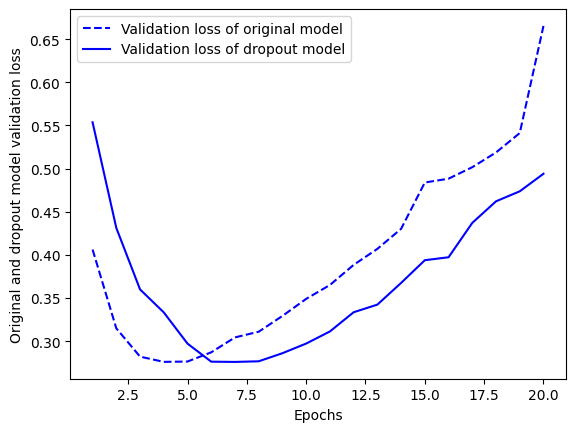

In [ ]:
val_loss_dropout = history_dropout.history['val_loss']
plt.plot(epochs, val_loss_original, 'b--', label='Validation loss of original model')
plt.plot(epochs, val_loss_dropout, 'b', label='Validation loss of dropout model')
plt.xlabel('Epochs')
plt.ylabel('Original and dropout model validation loss')
plt.legend()
plt.show()